In [1]:
"""
=================================================================
PHASE 2: PYTHON - EDA & FEATURE ENGINEERING
Project   : Insurance Policy Lapse & Renewal Analytics (SBI General)
Input     : SBI_Insurance_Data_Cleaned_Phase1.xlsx (Cleaned_Data sheet, from Excel Phase 1)
Output    : SBI_Insurance_Data_Phase2_Final.csv (goes into SQL Server next)
            + EDA chart images (for portfolio / report)
=================================================================
"""

'\n=================================================================\nPHASE 2: PYTHON - EDA & FEATURE ENGINEERING\nProject   : Insurance Policy Lapse & Renewal Analytics (SBI General)\nInput     : SBI_Insurance_Data_Cleaned_Phase1.xlsx (Cleaned_Data sheet, from Excel Phase 1)\nOutput    : SBI_Insurance_Data_Phase2_Final.csv (goes into SQL Server next)\n            + EDA chart images (for portfolio / report)\n=================================================================\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# nicer default look for all charts
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

In [4]:
INPUT_PATH = "SBI_Insurance_Data_Cleaned_Phase1.xlsx"
OUTPUT_CSV = "SBI_Insurance_Data_Phase2_Final.csv"

In [5]:
# -----------------------------------------------------------------
# 1. LOAD DATA
# -----------------------------------------------------------------
# We read the "Cleaned_Data" sheet — the output of the Excel Phase 1 work.
# The "RawData" sheet is ignored here; it's kept only as before/after evidence.
df = pd.read_excel(INPUT_PATH, sheet_name="Cleaned_Data")
 
print("Loaded shape:", df.shape)
print(df.dtypes)

Loaded shape: (60000, 20)
PolicyID                 str
CustomerName             str
Age                    int64
Gender                   str
City                     str
State                    str
ContactNumber        float64
Email                    str
Occupation               str
PolicyType               str
SalesChannel             str
PolicyStartDate          str
RenewalDueDate           str
PolicyTenureYears      int64
PaymentFrequency         str
PremiumAmount        float64
SumInsured           float64
ClaimsCount            int64
TotalClaimAmount     float64
PolicyStatus             str
dtype: object


In [6]:
# -----------------------------------------------------------------
# 2. FIX MIXED-FORMAT DATES
# -----------------------------------------------------------------
"""
This is the exact problem I flagged as too painful for Excel:
PolicyStartDate/RenewalDueDate contain SEVERAL different text formats mixed within the same column, e.g.:
   "08-08-2022"   -> DD-MM-YYYY
   "01 Dec 2019"  -> DD Mon YYYY
   "2021-02-08"   -> YYYY-MM-DD
   "02/26/2019"   -> MM/DD/YYYY (26 can't be a month, so this format is obvious here)
   "11/20/2019"   -> MM/DD/YYYY (same logic)
"""

'\nThis is the exact problem I flagged as too painful for Excel:\nPolicyStartDate/RenewalDueDate contain SEVERAL different text formats mixed within the same column, e.g.:\n   "08-08-2022"   -> DD-MM-YYYY\n   "01 Dec 2019"  -> DD Mon YYYY\n   "2021-02-08"   -> YYYY-MM-DD\n   "02/26/2019"   -> MM/DD/YYYY (26 can\'t be a month, so this format is obvious here)\n   "11/20/2019"   -> MM/DD/YYYY (same logic)\n'

In [7]:
def parse_mixed_date(value):
    """Try multiple known date formats and return the first that works.
    Returns pandas NaT (Not a Time) if nothing matches, instead of crashing."""
    if pd.isna(value):
        return pd.NaT
 
    value = str(value).strip()
 
    # list of formats actually present in our raw data generation
    known_formats = [
        "%d-%m-%Y",   # 08-08-2022
        "%Y-%m-%d",   # 2021-02-08
        "%d/%m/%Y",   # 26/02/2019 (rare, DD/MM/YYYY)
        "%m/%d/%Y",   # 02/26/2019 (common in this data, MM/DD/YYYY)
        "%d %b %Y",   # 01 Dec 2019
    ]
 
    for fmt in known_formats:
        try:
            return pd.to_datetime(value, format=fmt)
        except ValueError:
            continue  # this format didn't match, try the next one
 
    # last resort: let pandas guess (dayfirst=True biases ambiguous cases
    # like "01/02/2020" towards DD/MM instead of MM/DD, matching Indian convention)
    return pd.to_datetime(value, errors="coerce", dayfirst=True)

In [8]:
# apply the parser to both date columns
df["PolicyStartDate"] = df["PolicyStartDate"].apply(parse_mixed_date)
df["RenewalDueDate"] = df["RenewalDueDate"].apply(parse_mixed_date)

In [9]:
# how many dates couldn't be parsed at all? (worth reporting in your writeup)
print("\nUnparseable PolicyStartDate rows:", df["PolicyStartDate"].isna().sum())
print("Unparseable RenewalDueDate rows:", df["RenewalDueDate"].isna().sum())


Unparseable PolicyStartDate rows: 0
Unparseable RenewalDueDate rows: 0


In [10]:
# dropped rows where we truly can't tell when the policy started —
# a policy lapse project without a start date isn't usable for that row
df = df.dropna(subset=["PolicyStartDate"]).reset_index(drop=True)

In [11]:
# -----------------------------------------------------------------
# 3. FEATURE ENGINEERING
# -----------------------------------------------------------------
# We build extra columns that make the lapse-risk story clearer and
# will directly power the SQL views / Power BI measures later.
 
# reference "today" — using a fixed analysis date keeps results reproducible
# (using pd.Timestamp.now() would make numbers shift every time we rerun it)
ANALYSIS_DATE = pd.Timestamp("2024-12-31")

In [12]:
# how long the policy has existed, in days
df["PolicyAgeInDays"] = (ANALYSIS_DATE - df["PolicyStartDate"]).dt.days

In [13]:
# days left until renewal is due (negative = already overdue)
df["DaysToRenewal"] = (df["RenewalDueDate"] - ANALYSIS_DATE).dt.days

In [14]:
# claims per year of tenure — normalizes claim behaviour across policies
# of different ages instead of comparing raw claim counts directly
df["ClaimFrequencyRatio"] = df["ClaimsCount"] / df["PolicyTenureYears"].replace(0, 1)

In [15]:
# premium paid per year of tenure — helps spot pricing outliers
df["PremiumPerYearOfTenure"] = df["PremiumAmount"] / df["PolicyTenureYears"].replace(0, 1)

In [16]:
# bucket ages into bands — easier to read in charts/dashboards than raw age
def age_band(age):
    if age < 25:
        return "18-24"
    elif age < 35:
        return "25-34"
    elif age < 45:
        return "35-44"
    elif age < 55:
        return "45-54"
    elif age < 65:
        return "55-64"
    else:
        return "65+"
 
df["AgeBand"] = df["Age"].apply(age_band)

In [17]:
# simple RULE-BASED risk flag (not a machine learning model — just three
# common-sense conditions that tend to correlate with lapsing).
# This gives Power BI something to show even before/alongside an ML model.
df["IsHighRiskCustomer"] = (
    (df["PaymentFrequency"] == "Monthly") &   # monthly payers lapse more often
    (df["PolicyTenureYears"] <= 1) &          # new customers are less "sticky"
    (df["ClaimsCount"] == 0)                  # no claims filed = less engaged with the policy
).astype(int)
 
print("\nHigh-risk customers flagged:", df["IsHighRiskCustomer"].sum(),
      f"({df['IsHighRiskCustomer'].mean()*100:.1f}% of policies)")


High-risk customers flagged: 5146 (8.6% of policies)


In [18]:
# -----------------------------------------------------------------
# 4. SAVE FINAL CLEANED + ENRICHED DATA
# -----------------------------------------------------------------
# This CSV is what gets imported into SQL Server in Phase 3.
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved final dataset to: {OUTPUT_CSV}")
print("Final shape:", df.shape)


Saved final dataset to: SBI_Insurance_Data_Phase2_Final.csv
Final shape: (60000, 26)


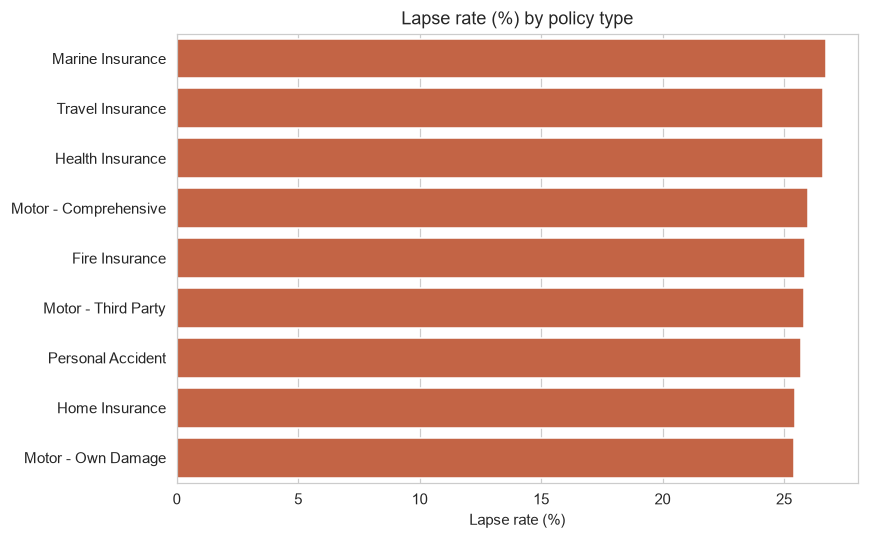

In [19]:
# -----------------------------------------------------------------
# 5. EXPLORATORY DATA ANALYSIS (EDA) - each chart as its own figure
# -----------------------------------------------------------------
 
# --- Chart 1: Lapse rate (%) by policy type ---
lapse_by_type = (
    df.groupby("PolicyType")["PolicyStatus"]
    .apply(lambda s: (s == "Lapsed").mean() * 100)
    .sort_values(ascending=False)
)
plt.figure(figsize=(8, 5))
sns.barplot(x=lapse_by_type.values, y=lapse_by_type.index, color="#D85A30")
plt.title("Lapse rate (%) by policy type")
plt.xlabel("Lapse rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("chart1_lapse_by_policytype.png")
plt.show()
plt.close()

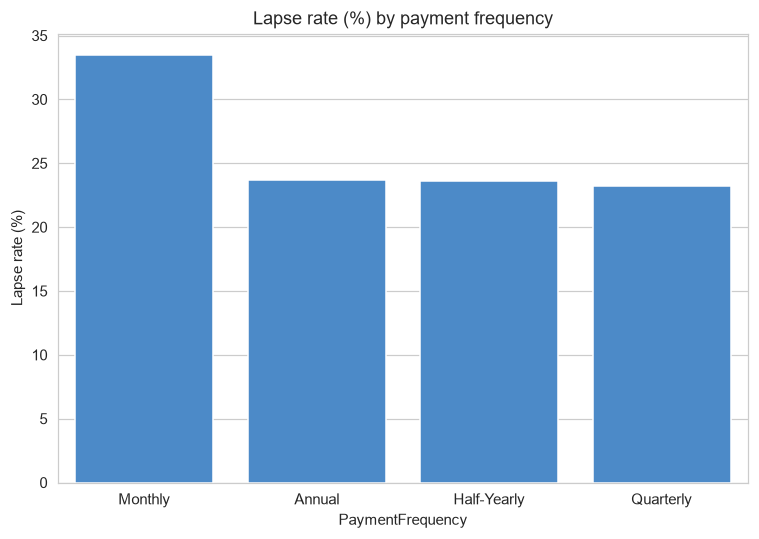

In [20]:
# --- Chart 2: Lapse rate (%) by payment frequency ---
lapse_by_freq = (
    df.groupby("PaymentFrequency")["PolicyStatus"]
    .apply(lambda s: (s == "Lapsed").mean() * 100)
    .sort_values(ascending=False)
)
plt.figure(figsize=(7, 5))
sns.barplot(x=lapse_by_freq.index, y=lapse_by_freq.values, color="#378ADD")
plt.title("Lapse rate (%) by payment frequency")
plt.ylabel("Lapse rate (%)")
plt.tight_layout()
plt.savefig("chart2_lapse_by_paymentfreq.png")
plt.show()
plt.close()

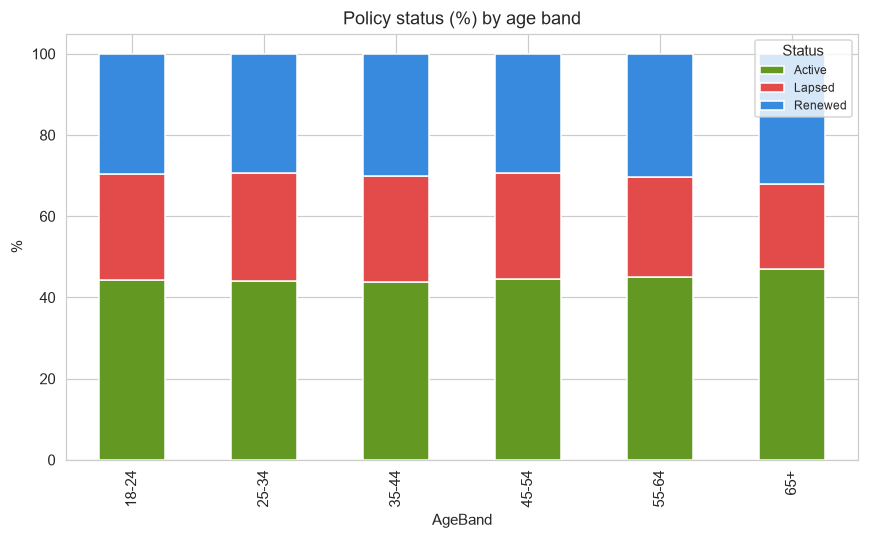

In [26]:
# --- Chart 3: Policy status mix (%) across age bands ---
ageband_status = pd.crosstab(df["AgeBand"], df["PolicyStatus"], normalize="index") * 100
ageband_status = ageband_status.reindex(["18-24", "25-34", "35-44", "45-54", "55-64", "65+"])
plt.figure(figsize=(8, 5))
ageband_status.plot(kind="bar", stacked=True, color=["#639922", "#E24B4A", "#378ADD"],
                     ax=plt.gca())
plt.title("Policy status (%) by age band")
plt.ylabel("%")
plt.legend(title="Status", fontsize=8)
plt.tight_layout()
plt.savefig("chart3_status_by_ageband.png")
plt.show()
plt.close()

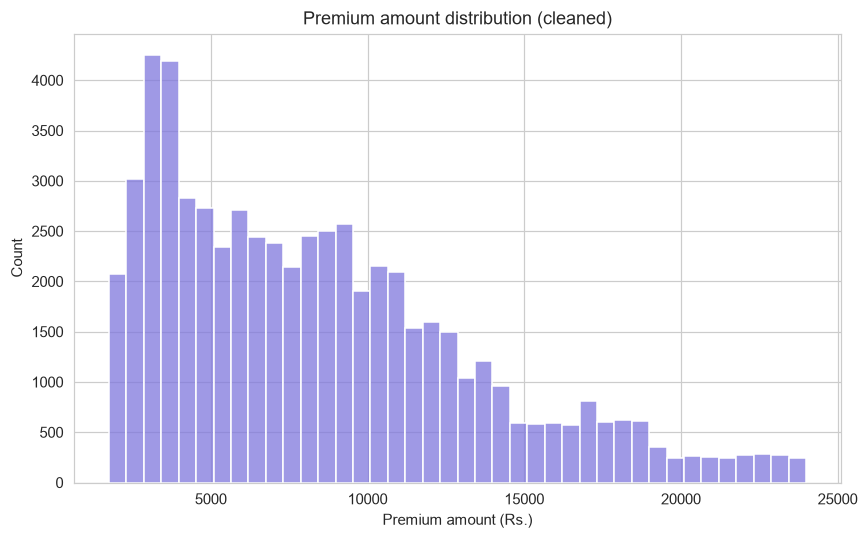

In [28]:
# --- Chart 4: Premium amount distribution ---
plt.figure(figsize=(8, 5))
sns.histplot(df["PremiumAmount"], bins=40, color="#7F77DD")
plt.title("Premium amount distribution (cleaned)")
plt.xlabel("Premium amount (Rs.)")
plt.tight_layout()
plt.savefig("chart4_premium_distribution.png")
plt.show()
plt.close()

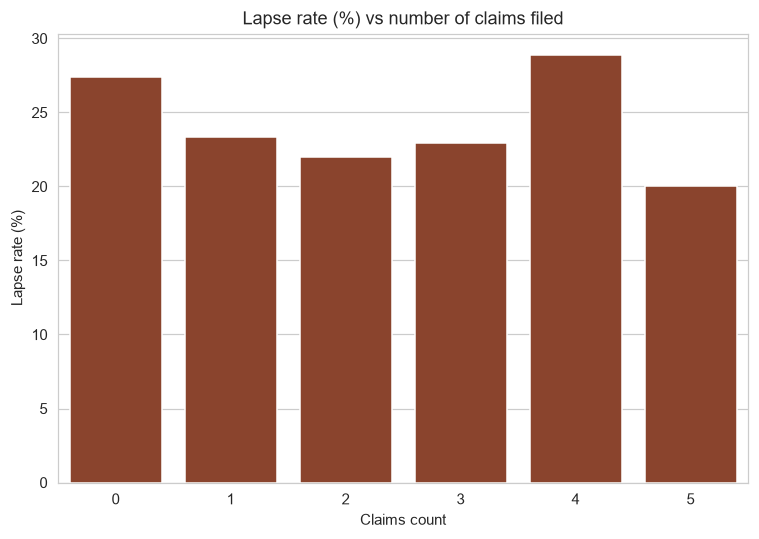

In [23]:
# --- Chart 5: claims count vs lapse rate ---
claim_lapse = (
    df.groupby("ClaimsCount")["PolicyStatus"]
    .apply(lambda s: (s == "Lapsed").mean() * 100)
)
claim_lapse = claim_lapse[claim_lapse.index <= 5]
plt.figure(figsize=(7, 5))
sns.barplot(x=claim_lapse.index, y=claim_lapse.values, color="#993C1D")
plt.title("Lapse rate (%) vs number of claims filed")
plt.xlabel("Claims count")
plt.ylabel("Lapse rate (%)")
plt.tight_layout()
plt.savefig("chart5_claims_vs_lapse.png")
plt.show()
plt.close()

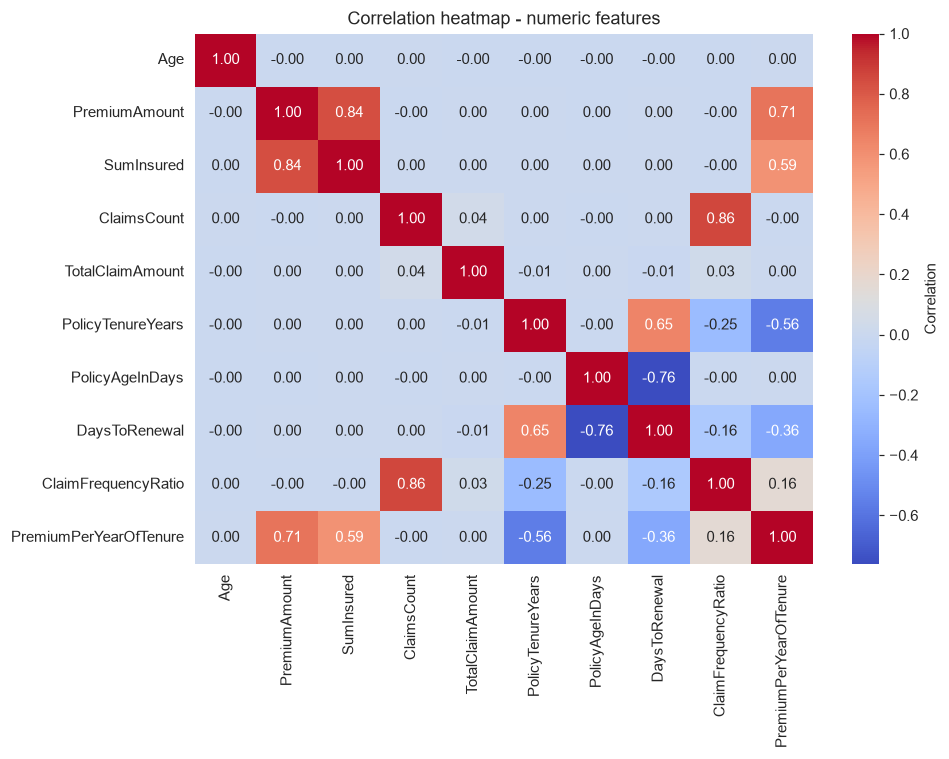

In [24]:
# --- Chart 6: correlation heatmap of numeric features ---
numeric_cols = ["Age", "PremiumAmount", "SumInsured", "ClaimsCount", "TotalClaimAmount",
                 "PolicyTenureYears", "PolicyAgeInDays", "DaysToRenewal",
                 "ClaimFrequencyRatio", "PremiumPerYearOfTenure"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            cbar_kws={"label": "Correlation"})
plt.title("Correlation heatmap - numeric features")
plt.tight_layout()
plt.savefig("chart6_correlation_heatmap.png")
plt.show()
plt.close()

In [25]:
print("All 6 charts saved as individual PNG files.")

All 6 charts saved as individual PNG files.
